In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import utulek

utulek.platform.import_globals_notebook(globals())

base_module = utulek
IS_NOTEBOOK_KERNEL_CODE = True
NOTEBOOK_NAME = 2026_07_27-t2i.ipynb
ASSET_PATH = /home/gilgamesh/main.syncthing/utulek/experiment/2026_07_27-t2i.ipynb.asset/
Loaded `/home/gilgamesh/main.syncthing/utulek/experiment/.env`.
torch: ['NVIDIA GeForce GTX 1080 Ti']
tf: /device:GPU:0
jax: [CudaDevice(id=0)]


In [ ]:
from diffusers import DiffusionPipeline

base = DiffusionPipeline.from_pretrained(
	"stabilityai/stable-diffusion-xl-base-1.0",
	torch_dtype=torch.float16,
	variant="fp16",
	use_safetensors=True)
base.to("cpu")
torch.cuda.empty_cache()
refiner = DiffusionPipeline.from_pretrained(
	"stabilityai/stable-diffusion-xl-refiner-1.0",
	text_encoder_2=base.text_encoder_2,
	vae=base.vae,
	torch_dtype=torch.float16,
	use_safetensors=True,
	variant="fp16",
)
refiner.to("cpu")
torch.cuda.empty_cache()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, du

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, du

In [10]:
def prompt(prompt: str,
	n_steps: int = 40,
	high_noise_frac: float = 0.8):
	base.to("cuda")
	# base.enable_model_cpu_offload()
	image = base(
		prompt=prompt,
		num_inference_steps=n_steps,
		denoising_end=high_noise_frac,
		output_type="latent",
	).images
	base.to("cpu")
	torch.cuda.empty_cache()

	refiner.to("cuda")
	# refiner.enable_model_cpu_offload()
	image = refiner(
		prompt=prompt,
		num_inference_steps=n_steps,
		denoising_start=high_noise_frac,
		image=image,
	).images[0]
	refiner.to("cpu")
	torch.cuda.empty_cache()
	return image

  0%|          | 0/80 [00:00<?, ?it/s]

Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, du

  0%|          | 0/20 [00:00<?, ?it/s]

/home/gilgamesh/main.syncthing/utulek/.venv/lib/python3.11/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl_img2img.py:896: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fa

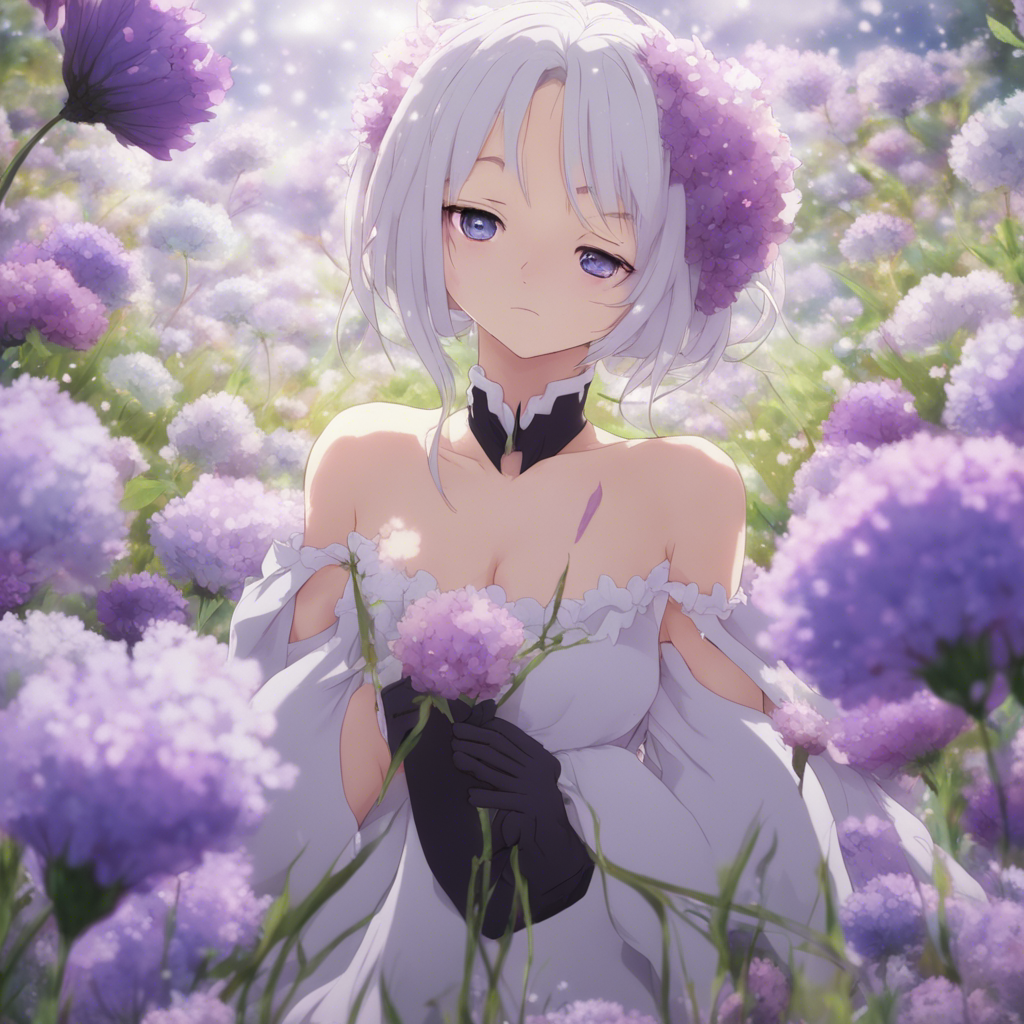

In [11]:
image = prompt(
	"emilia from re zero anime in a field of flowers, highly detailed, high budget hollywood movie, cinemascope, moody, epic, gorgeous, film grain",
	n_steps=100)
image.save("../snowfall/t2i.png")
image